# Universidade Federal de São João del-Rei

# Machine Learning Aplicado à Engenharia

# Trabalho 2 (T2) — Modelagem, Validação e Comparação de Modelos de Aprendizado de Máquina

**Tema:** Análise Exploratória de Sinais EEG para Monitoramento e Classificação de Estados de Sono em Janelas de 30 Segundos

**Base utilizada:** _Sleep-EDF Database Expanded_

**Fonte:** https://www.physionet.org/content/sleep-edfx/1.0.0/

# Referência da Base

- B Kemp, AH Zwinderman, B Tuk, HAC Kamphuisen, JJL Oberyé. _Analysis of a sleep-dependent neuronal feedback loop: the slow-wave microcontinuity of the EEG_. IEEE-BME 47(9):1185-1194 (2000).

# Citação Padrão para PhysioNet

- Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, PC, Mark, R., ... & Stanley, HE (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

**Integrantes do grupo:**
- Ícaro Ferreira dos Santos
- Wendell Christian Calixto Pinto
- Gabriel Augusto Silva Batista

**Repositório do grupo:**  
https://github.com/gabrielbtt/analise-estados-sono-eeg

# Convenção de Cores para Identificar Contribuições
- <font color="blue">Azul:</font> Ícaro Ferreira dos Santos
- <font color="green">Verde:</font> Wendell Christian Calixto Pinto
- <font color="red">Vermelho:</font> Gabriel Augusto Silva Batista

# Definição do Problema <font color="blue">(Ícaro)</font>

O problema escolhido neste trabalho consiste na **classificação automática dos estágios do sono** a partir de sinais de EEG do canal Fpz-Cz. A análise manual de polissonografias é um processo demorado, subjetivo e altamente dependente da experiência do técnico. Um sistema automatizado torna o diagnóstico mais rápido, objetivo e acessível, reduzindo a variabilidade entre profissionais.

Trata-se de um **problema de classificação supervisionada multiclasse**, cuja variável alvo (`y`) é a coluna `estagio`, contendo cinco categorias discretas: Vigília (W), N1, N2, N3 (sono profundo) e REM.

As variáveis de entrada (atributos `X`) são compostas por 26 características extraídas de cada época de 30 segundos, divididas em dois grupos principais:  
- Características Estatísticas: média, desvio padrão, variância, valor RMS, assimetria e curtose da amplitude do sinal (em µV);  
- Características Espectrais: potência absoluta e relativa nas bandas Delta (0,5–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz) e Beta (13–30 Hz), além de razões espectrais (como Delta/Alpha e Delta/Theta).

Essas variáveis foram selecionadas porque capturam propriedades fisiológicas críticas dos estágios do sono. A **potência delta** discrimina o sono profundo (N3), o **valor RMS** reflete a energia total do sinal em cada época, e a **assimetria** ajuda a identificar a instabilidade característica da vigília e do sono leve.

Apesar dos avanços, a base apresenta algumas limitações importantes, conforme o **Trabalho 1 (T1)**: o estágio N2 é predominante (29,73% das épocas), enquanto o N1 é raro (6,90%), o que pode enviesar o modelo. Além disso, estágios fisiologicamente próximos, como N1 e REM, apresentam assinaturas estatísticas semelhantes, dificultando a definição de fronteiras de decisão. Por fim, diferenças individuais entre pacientes podem afetar a capacidade de generalização do modelo.

# Descrição da Base de Dados

A base utilizada é a *Sleep-EDF Database Expanded*, obtida via [PhysioNet](https://www.physionet.org/content/sleep-edfx/1.0.0/). Trata-se de um conjunto de dados reais de polissonografia voltado para o estudo da arquitetura do sono.

Os dados dos sinais polissonográficos (arquivos com extensão .PSG.edf) estão no formato EDF (*European Data Format*), contendo EEG (eletrodos Fpz-Cz e Pz-Oz), EOG (horizontal), EMG submentoniano, um marcador de evento e, geralmente, também sinais de respiração oronasal e temperatura corporal retal. Os hipnogramas, anotações dos estágios do sono, armazenados em arquivos com extensão *.Hypnogram.edf, estão no formato EDF+. Os arquivos são nomeados no padrão SC4 ssN EO-PSG.edf, em que "ss" corresponde ao número do sujeito e "N" à noite de coleta.

> **Sinais Utilizados:** Foram extraídas características dos canais de EEG Fpz-Cz e Pz-Oz, com frequência de amostragem de 100 Hz.

> Os hipnogramas foram anotados manualmente por técnicos treinados seguindo o padrão Rechtschaffen & Kales, dividindo o registro em épocas de 30 segundos.

Além disso, problema consiste em uma classificação multiclasse com 5 categorias discretas:

- W (Vigília): momento em que a pessoa está acordada ou quase acordando;
- N1: sono leve de transição (fácil de acordar);
- N2: sono mais estável, que ocupa a maior parte da noite;
- N3: sono profundo, importante para recuperação física do corpo;
- R (REM): sono dos sonhos, essencial para a memória e o equilíbrio emocional.

**Escopo do Trabalho**

Para este trabalho, foram utilizados os arquivos do banco Sleep-EDF Expanded no intervalo entre `SC4001E0-PSG.edf` e `SC4012EC-Hypnogram.edf`. Essa expansão permite treinar o modelo com um volume significativamente maior de épocas em comparação ao estudo exploratório inicial, que utilizou apenas uma noite de um único paciente.

A base consolidada (`dados_epocas.csv`) foi dividida em conjuntos de treino e teste utilizando dados de **pacientes distintos**, de forma a garantir uma avaliação mais realista da capacidade de generalização do modelo para novos indivíduos.

# Conclusões do T1 e Motivação para o T2

A análise exploratória realizada no T1 consolidou a base `Sleep-EDF Expanded` como um conjunto de dados estruturado e tecnicamente justificado para tarefas de aprendizado de máquina. As principais conclusões que motivam este Trabalho 2 são:

- A **Potência Delta** é a característica mais robusta para distinguir o sono profundo (N3), com valores cerca de 14 vezes superiores ao sono leve (N1).
- O valor **RMS** validou a realidade biológica do sono, sendo máximo no estágio N3 devido à grande amplitude das ondas lentas.
- A segmentação dos sinais brutos em épocas de 30 segundos reduziu o volume de dados de aproximadamente 2,5 milhões de amostras para 841 épocas interpretáveis, tornando o conjunto de dados mais compacto e adequado à aplicação de modelos de classificação multiclasse.

Embora o sono seja um processo cíclico e sequencial, no qual cada estágio é influenciado pelo anterior, como evidenciado pelo hipnograma no T1, o objetivo deste trabalho é realizar uma classificação multiclasse baseada nas características extraídas individualmente de cada época de 30 segundos (tais como valor RMS e potência nas bandas de frequência).

Dessa forma, cada janela de 30 segundos é tratada como uma amostra independente para o classificador. Essa abordagem justifica a concatenação dos dados de todas as noites e pacientes em um único *DataFrame* para treinamento. No entanto, devido à natureza temporal inerente ao sono, dois cuidados críticos devem ser observados:

  1. Para garantir a generalização e evitar o "vazamento de dados" (*data leakage*), a separação entre treino e teste deve ser feita por noites inteiras ou pacientes, garantindo que o modelo aprenda padrões universais e não apenas decore um indivíduo específico.
  2. A ordem sequencial dentro de cada noite deve ser preservada para futuras análises de contexto temporal e transições biológicas.

# Descrição das Variáveis

O conjunto de dados consolidado (`dados_epocas.csv`) contém **29 colunas**, organizadas da seguinte forma:

- Variáveis Identificadoras: `chavepar`, `indice_epoca` e `estagio` (variável alvo).
- Características Estatísticas (*Features*): média, desvio padrão, variância, valor RMS, assimetria e curtose da amplitude do sinal (em µV).
- Características Espectrais (*Features*): potência absoluta e relativa nas bandas Delta (0,5–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz) e Beta (13–30 Hz), além de razões espectrais (ex.: Delta/Alpha e Delta/Theta).

Essas variáveis foram extraídas de cada janela de 30 segundos e representam os principais padrões estatísticos e espectrais do sinal EEG, fundamentais para a identificação automática dos estágios do sono.

# Instruções para Obtenção dos Dados

Devido ao grande volume de dados da base **Sleep-EDF Database Expanded** e às restrições de tamanho de arquivo do GitHub, os arquivos brutos não foram incluídos neste repositório. Para que este notebook seja executado corretamente e os resultados sejam reproduzidos, siga as instruções abaixo.

### 1. Clonar o repositório
Execute o seguinte comando para clonar o repositório do projeto:

In [ ]:
# Clonar o repositório
!git clone https://github.com/gabrielbtt/analise-estados-sono-eeg.git

Cloning into 'analise-estados-sono-eeg'...
remote: Enumerating objects: 409, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 409 (delta 142), reused 18 (delta 18), pack-reused 183 (from 1)
Receiving objects: 100% (409/409), 97.50 MiB | 17.92 MiB/s, done.
Resolving deltas: 100% (199/199), done.


### 2. Acesse a fonte oficial
Acesse o repositório oficial da base de dados no **[PhysioNet](https://www.physionet.org/content/sleep-edfx/1.0.0/#files-panel)**

### 3. Localize os arquivos
Role a página até o final do site. No painel de arquivos (*Files*), localize e navegue até a pasta `sleep-cassette`.

### 4. Realize o download
Baixe os **pares de arquivos `.edf`** correspondentes a cada registro:
- Arquivo de sinal PSG (`*-PSG.edf`)
- Arquivo de hipnograma (`*-Hypnogram.edf`)

> **Nota:** Para este trabalho, foram utilizados os arquivos no intervalo de `SC4001E0-PSG.edf` até `SC4012EC-Hypnogram.edf`.

### 5. Organize o diretório
Salve **obrigatoriamente** todos os arquivos baixados no seguinte caminho, para garantir o funcionamento correto do código de carregamento `analise-estados-sono-eeg/dados/edfs_originais/`

Após essa organização, o notebook poderá ser executado normalmente e os resultados poderão ser reproduzidos.

# Carregamento da Base de Dados

In [8]:
# Entrar na pasta do projeto
%cd analise-estados-sono-eeg

c:\Users\ifs67\ml_app_eng\trabalhos_computacionais\analise-estados-sono-eeg


In [ ]:
# Verificar se os arquivos estão lá
!dir

In [ ]:
%pip install mne

In [256]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from IPython.display import display

# Carregamento da Base de Dados
# Pasta com os arquivos EDF originais
dados_dir = Path("dados/edfs_originais")
# Pasta onde o CSV final sera salvo
saida_dir = Path("dados/brutos")
dados_dir

# Leitura e organização
# Extrai a chave comum usada para juntar PSG e hypnograma
def peganome(filename: str) -> str:
    base = Path(filename).name.split("-")[0]
    return base[:7]

# Procura os arquivos e monta os pares correspondentes
def encontrapar(data_dir: Path, prefix="SC"):
    arquivospsg = sorted(data_dir.glob(f"{prefix}*-PSG.edf"))
    arquivoshyp = sorted(data_dir.glob(f"{prefix}*-Hypnogram.edf"))

    print(f"PSG encontrados: {len(arquivospsg)}")
    print(f"Hypnogram encontrados: {len(arquivoshyp)}")

    dicpsg = {peganome(arquivo.name): arquivo for arquivo in arquivospsg}
    dichyp = {peganome(arquivo.name): arquivo for arquivo in arquivoshyp}

    print("Chaves PSG:", list(dicpsg.keys()))
    print("Chaves Hyp:", list(dichyp.keys()))

    chaves_comuns = sorted(set(dicpsg) & set(dichyp))
    print(f"Chaves em comum: {len(chaves_comuns)}")

    return [(k, dicpsg[k], dichyp[k]) for k in chaves_comuns]

# Gera a lista de pares validos
pares = encontrapar(dados_dir, prefix="SC")
len(pares), pares[:5]

# Escolher quantidade de noites pra analisar
totalpares = 10
# Seleciona só os primeiros pares para teste
selecpares = pares[:totalpares]
selecpares

# Conferir se par foi carregado corretamente
chavepar, caminhopsg, caminhohyp = selecpares[0] # pega só o primeiro par

# le o sinal bruto e as anotacoes do hypnograma
bruto = mne.io.read_raw_edf(caminhopsg, preload=False, infer_types=True, verbose="ERROR")
anot = mne.read_annotations(caminhohyp)

print(f"Chave do par: {chavepar}")
print(f"PSG: {caminhopsg}")
print(f"Hypnograma: {caminhohyp}")
print(f"Canais: {bruto.ch_names}")
print(f"Frequencia de amostragem: {bruto.info['sfreq']} Hz")
print("\nTabela 1: Primeiras anotacoes")
# Mostra um resumo inicial para validar as classes e os tempos
print(pd.DataFrame({
    "Inicio(s)": anot.onset[:10],
    "Duracao(s)": anot.duration[:10],
    "Classificacao": anot.description[:10]
}))

# Juntar em blocos de 30s, juntar estágio 3 e 4, selecionar canal principal, juntar com anotações, remover longas partes do acordado, extrair dados
# Tamanho padrão de cada época em segundos
SEGUNDOS_EPOCA = 30.0
# Faixa do filtro passa-banda aplicada ao EEG
FREQ_CORTE_BAIXA = 0.5
FREQ_CORTE_ALTA = 30.0
# Canal principal usado na análise
CANAL_EEG = "Fpz-Cz"
# Pares e pasta final reaproveitados nas próximas células
pares_sel = selecpares
PASTA_SAIDA = saida_dir
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

# Mapeia os rótulos do hypnograma para ids numéricos
AnotacaoParaId = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4, # juntar estagio 3 e 4
    "Sleep stage 4": 4, # juntar estagio 3 e 4
    "Sleep stage R": 5,
}

# Traduz os ids para os nomes das classes finais
IdPraClassificacao = {
    1: "Acordado",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM"
}

# Valida se o canal desejado existe no arquivo lido
def escolher_canal(bruto, escolha="Fpz-Cz"):
    if escolha in bruto.ch_names:
        return escolha
    else:
        raise ValueError(f"Canal {escolha} nao encontrado. Canais disponiveis: {bruto.ch_names}")

# Calcula a potência de uma faixa de frequência usando Welch
def calcular_potencia_banda(x, fs, fmin, fmax):
    amostras_janela = min(len(x), int(4 * fs))
    frequencias, densidade_potencia = welch(x, fs=fs, nperseg=amostras_janela)
    mascara_banda = (frequencias >= fmin) & (frequencias <= fmax)
    if not np.any(mascara_banda):
        return 0.0
    return trapezoid(densidade_potencia[mascara_banda], frequencias[mascara_banda])

# Extrai estatísticas simples e potências por banda de uma época
def extrair_dados_epocas(x, fs):
    delta = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=4)
    theta = calcular_potencia_banda(x, fs=fs, fmin=4, fmax=8)
    alpha = calcular_potencia_banda(x, fs=fs, fmin=8, fmax=13)
    beta = calcular_potencia_banda(x, fs=fs, fmin=13, fmax=30)
    total = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=30)
    eps = 1e-12
    return {
        "media": np.mean(x),
        "desvio_padrao": np.std(x, ddof=1),
        "variancia": np.var(x, ddof=1),
        "minimo": np.min(x),
        "maximo": np.max(x),
        "pico_a_pico": np.ptp(x),
        "valor_rms": np.sqrt(np.mean(x**2)),
        "assimetria": skew(x, bias=False),
        "curtose_excesso": kurtosis(x, fisher=True, bias=False),
        "potencia_delta": delta,
        "potencia_theta": theta,
        "potencia_alpha": alpha,
        "potencia_beta": beta,
        "potencia_total": total,
        "relativo_delta": delta / (total + eps),
        "relativo_theta": theta / (total + eps),
        "relativo_alpha": alpha / (total + eps),
        "relativo_beta": beta / (total + eps),
        "razao_delta_theta": delta / (theta + eps),
        "razao_delta_alpha": delta / (alpha + eps),
    }

PSG encontrados: 4
Hypnogram encontrados: 4
Chaves PSG: ['SC4001E', 'SC4002E', 'SC4011E', 'SC4012E']
Chaves Hyp: ['SC4001E', 'SC4002E', 'SC4011E', 'SC4012E']
Chaves em comum: 4
Chave do par: SC4001E
PSG: dados\edfs_originais\SC4001E0-PSG.edf
Hypnograma: dados\edfs_originais\SC4001EC-Hypnogram.edf
Canais: ['Fpz-Cz', 'Pz-Oz', 'horizontal', 'oro-nasal', 'submental', 'rectal', 'Event marker']
Frequencia de amostragem: 100.0 Hz

Tabela 1: Primeiras anotacoes
   Inicio(s)  Duracao(s)  Classificacao
0        0.0     30630.0  Sleep stage W
1    30630.0       120.0  Sleep stage 1
2    30750.0       390.0  Sleep stage 2
3    31140.0        30.0  Sleep stage 3
4    31170.0        30.0  Sleep stage 2
5    31200.0       150.0  Sleep stage 3
6    31350.0        30.0  Sleep stage 4
7    31380.0        60.0  Sleep stage 3
8    31440.0        60.0  Sleep stage 4
9    31500.0        30.0  Sleep stage 3


# Preparação dos Dados

In [257]:
# Encontra o intervalo útil do sono com margem antes e depois
def lim_sono(anot, margem_segundos=1800):
    # Classes consideradas como sono real
    estagios_sono = {
        "Sleep stage 1",
        "Sleep stage 2",
        "Sleep stage 3",
        "Sleep stage 4",
        "Sleep stage R",
    }
    ind_sono = np.where(np.isin(anot.description, list(estagios_sono)))[0]

    # Se não houver sono anotado, mantém a janela inteira
    if len(ind_sono) == 0:
        return 0, anot.onset[-1] + anot.duration[-1]

    primeiro_ind = ind_sono[0]
    ultimo_ind = ind_sono[-1]

    ini_recorte = max(0, anot.onset[primeiro_ind] - margem_segundos)
    fim_recorte = anot.onset[ultimo_ind] + anot.duration[ultimo_ind] + margem_segundos

    return ini_recorte, fim_recorte


In [258]:
# Recorta as anotações para ficar apenas com a janela útil do sono
def recortar_anotacoes_sono(anot, margem_segundos=1800):
    ini_recorte, fim_recorte = lim_sono(anot, margem_segundos=margem_segundos)
    anot_recortada = anot.copy()
    anot_recortada.crop(tmin=ini_recorte, tmax=fim_recorte)
    return anot_recortada

# Processa um par PSG + hypnograma e devolve um dataframe de épocas
def processar_par(caminhopsg, caminhohyp, chavepar):
    # carrega o sinal e as anotacoes do par atual
    bruto = mne.io.read_raw_edf(caminhopsg, preload=True, infer_types=True, verbose="ERROR")
    anot = mne.read_annotations(caminhohyp)

    # Limita a análise a janela útil do sono
    anot = recortar_anotacoes_sono(anot, margem_segundos=1800)
    bruto.set_annotations(anot, emit_warning=False)

    # Escolhe o canal principal e aplica o filtro
    canal_alvo = escolher_canal(bruto, CANAL_EEG)
    bruto.pick([canal_alvo])
    bruto.filter(FREQ_CORTE_BAIXA, FREQ_CORTE_ALTA, fir_design="firwin", verbose="ERROR")

    fs = float(bruto.info["sfreq"])

    # Transforma as anotações em eventos de 30 segundos
    eventos, _ = mne.events_from_annotations(
        bruto,
        event_id=AnotacaoParaId,
        chunk_duration=SEGUNDOS_EPOCA,
        verbose="ERROR",
    )

    # Gera as épocas alinhadas aos eventos encontrados
    epocas = mne.Epochs(
        bruto,
        eventos,
        event_id=None,
        tmin=0.0,
        tmax=SEGUNDOS_EPOCA - 1.0 / fs,
        baseline=None,
        preload=True,
        verbose="ERROR",
    )

    dados = epocas.get_data(copy=False)
    codigos_estagios = epocas.events[:, 2]
    amostras_eventos = epocas.events[:, 0]

    linhas = []
    for i in range(len(epocas)):
        x = dados[i, 0, :]
        # extrai as features da epoca atual
        feat = extrair_dados_epocas(x, fs=fs)

        # Monta uma linha com metadados e features das épocas
        linha = {
            "chavepar": chavepar,
            "arquivo_psg": caminhopsg.name,
            "arquivo_hyp": caminhohyp.name,
            "canal": canal_alvo,
            "frequencia_amostragem_hz": fs,
            "indice_epoca": i,
            "inicio_epoca_s": amostras_eventos[i] / fs,
            "id_estagio": int(codigos_estagios[i]),
            "estagio": IdPraClassificacao.get(int(codigos_estagios[i]), "OUTRO"),
        }
        linha.update(feat)
        linhas.append(linha)

    return pd.DataFrame(linhas)

# Exemplo com o primeiro par selecionado
df_exemplo = processar_par(caminhopsg, caminhohyp, chavepar)
print("Tabela 2: Estrutura do DataFrame de exemplo")
print(f"{chavepar}: {len(df_exemplo)} epocas")
df_exemplo.head()


Tabela 2: Estrutura do DataFrame de exemplo
SC4001E: 841 epocas


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_theta,potencia_alpha,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,3.322136e-11,5.745580e-12,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,4.281629e-11,4.770206e-12,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,6.198571e-11,5.257595e-12,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,4.731464e-11,6.219261e-12,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,4.000793e-11,5.459383e-12,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367


In [259]:
import traceback

dfs = []

# Processa todos os pares selecionados e acumula os dataframes
for chavepar, caminhopsg, caminhohyp in pares_sel:
    print(f"\nProcessando {chavepar}")
    print("PSG:", caminhopsg)
    print("HYP:", caminhohyp)

    try:
        df_i = processar_par(caminhopsg, caminhohyp, chavepar)
        dfs.append(df_i)
        print(f"{chavepar}: {len(df_i)} epocas")
    except Exception as e:
        print(f"Erro em {chavepar}: {type(e).__name__}: {e}")
        traceback.print_exc()

if len(dfs) == 0:
    raise RuntimeError(
        "Nenhum arquivo foi processado com sucesso. "
        "Veja os erros impressos acima."
    )

# Junta tudo em um único dataframe e salva em CSV
df = pd.concat(dfs, ignore_index=True)
df.to_csv(PASTA_SAIDA / "dados_epocas.csv", index=False)

print(f"\nTabela 3: Primeiras 5 linhas do par SC4001E")

df.head()



Processando SC4001E
PSG: dados\edfs_originais\SC4001E0-PSG.edf
HYP: dados\edfs_originais\SC4001EC-Hypnogram.edf
SC4001E: 841 epocas

Processando SC4002E
PSG: dados\edfs_originais\SC4002E0-PSG.edf
HYP: dados\edfs_originais\SC4002EC-Hypnogram.edf
SC4002E: 1127 epocas

Processando SC4011E
PSG: dados\edfs_originais\SC4011E0-PSG.edf
HYP: dados\edfs_originais\SC4011EH-Hypnogram.edf
SC4011E: 1103 epocas

Processando SC4012E
PSG: dados\edfs_originais\SC4012E0-PSG.edf
HYP: dados\edfs_originais\SC4012EC-Hypnogram.edf
SC4012E: 1186 epocas

Tabela 3: Primeiras 5 linhas do par SC4001E


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_theta,potencia_alpha,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,3.322136e-11,5.745580e-12,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,4.281629e-11,4.770206e-12,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,6.198571e-11,5.257595e-12,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,4.731464e-11,6.219261e-12,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,4.000793e-11,5.459383e-12,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367


In [260]:
# Carregamento da base processada
df = pd.read_csv("dados/brutos/dados_epocas.csv")
print("Shape do DataFrame:", df.shape)

print("\nTabela 4: Tipos de dados")
display(pd.DataFrame(df.dtypes, columns=["Tipo"]))

Shape do DataFrame: (4257, 29)

Tabela 4: Tipos de dados


,Tipo
chavepar,str
arquivo_psg,str
arquivo_hyp,str
canal,str
frequencia_amostragem_hz,float64
indice_epoca,int64
inicio_epoca_s,float64
id_estagio,int64
estagio,str
media,float64


## Descrição das Variáveis

**Tabela 5: Descrição das Variáveis**

| Variável                    | Unidade     | Descrição |
|-----------------------------|-------------|-----------|
| chavepar                    | -           | Identificador do paciente e noite |
| arquivo_psg                 | -           | Nome do arquivo PSG original |
| arquivo_hyp                 | -           | Nome do arquivo de hipnograma |
| canal                       | -           | Canal de EEG utilizado (Fpz-Cz) |
| frequencia_amostragem_hz    | Hz          | Frequência de amostragem do sinal |
| indice_epoca                | -           | Índice da época de 30 segundos |
| inicio_epoca_s              | segundos    | Tempo de início da época na gravação |
| id_estagio                  | -           | Código numérico do estágio do sono |
| estagio                     | -           | Estágio do sono (Acordado, N1, N2, N3, REM) |
| media                       | µV          | Média da amplitude do sinal na época |
| desvio_padrao               | µV          | Desvio padrão da amplitude |
| variancia                   | µV²         | Variância da amplitude |
| minimo                      | µV          | Valor mínimo da amplitude na época |
| maximo                      | µV          | Valor máximo da amplitude na época |
| pico_a_pico                 | µV          | Diferença entre valor máximo e mínimo |
| valor_rms                   | µV          | Valor RMS (_root mean square_) |
| assimetria                  | -           | Medida de assimetria da distribuição |
| curtose_excesso             | -           | Medida de curtose (excesso) da distribuição |
| potencia_delta              | µV²/Hz      | Potência na banda delta (0,5–4 Hz) |
| potencia_theta              | µV²/Hz      | Potência na banda theta (4–8 Hz) |
| potencia_alpha              | µV²/Hz      | Potência na banda alpha (8–13 Hz) |
| potencia_beta               | µV²/Hz      | Potência na banda beta (13–30 Hz) |
| potencia_total              | µV²/Hz      | Potência total na faixa 0,5–30 Hz |
| relativo_delta              | -           | Potência relativa na banda delta |
| relativo_theta              | -           | Potência relativa na banda theta |
| relativo_alpha              | -           | Potência relativa na banda alpha |
| relativo_beta               | -           | Potência relativa na banda beta |
| razao_delta_theta           | -           | Razão entre potência delta e theta |
| razao_delta_alpha           | -           | Razão entre potência delta e alpha |

## Estruturação Inicial dos Dados
- Total de observações: **4257 épocas** de 30 segundos.
- Cada linha representa uma janela de 30 segundos com suas _features_ (características) extraídas.
- A coluna `estagio` já contém os rótulos clínicos (Acordado, N1, N2, N3, REM).

## Observações Sobre Formato, Tipos e Consistência

In [261]:
df = pd.read_csv("dados/brutos/dados_epocas.csv")

# Verificação de valores ausentes
missing = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual (%)': (df.isnull().mean() * 100).round(4)
})

print("Tabela 6: Valores ausentes por coluna")
display(missing)

print(f"\nNúmero total de épocas: {len(df)}")
print(f"Número de estágios únicos: {df['estagio'].nunique()}")

# Distribuição dos estágios com quantidade E porcentagem
dist = pd.DataFrame({
    'Quantidade': df['estagio'].value_counts().sort_index(),
    'Porcentagem (%)': (df['estagio'].value_counts(normalize=True).sort_index() * 100).round(2)
})

print("\nTabela 7: Distribuição dos estágios do sono")
display(dist)

Tabela 6: Valores ausentes por coluna


,Valores Ausentes,Percentual (%)
chavepar,0,0.0
arquivo_psg,0,0.0
arquivo_hyp,0,0.0
canal,0,0.0
frequencia_amostragem_hz,0,0.0
indice_epoca,0,0.0
inicio_epoca_s,0,0.0
id_estagio,0,0.0
estagio,0,0.0
media,0,0.0



Número total de épocas: 4257
Número de estágios únicos: 5

Tabela 7: Distribuição dos estágios do sono


,Quantidade,Porcentagem (%)
estagio,,
Acordado,690,16.21
N1,318,7.47
N2,1845,43.34
N3,718,16.87
REM,686,16.11


# Análise de Desbalanceamento de Classes

A base de dados é inerentemente **desbalanceada**, refletindo a arquitetura natural do sono humano:

- Classe Majoritária: Estágio **N2** (43,34% das épocas).
- Classe Minoritária: Estágio **N1** (apenas 7,47% das épocas). Este desbalanceamento exige atenção especial na escolha das métricas de avaliação (como F1-score e balanced accuracy), para garantir que o modelo não ignore o estágio menos frequente em favor da acurácia global.

# Divisão dos Dados (Treino e Teste)

Nesta etapa, o conjunto de dados consolidado no arquivo `dados_epocas.csv` será particionado para permitir o treinamento e a avaliação rigorosa dos modelos de aprendizado de máquina.

- Utilizaremos uma divisão de 70% dos dados para treinamento e 30% para teste.
- Para lidar com o desbalanceamento inerente aos estágios do sono, a divisão será estratificada baseada na variável alvo (`id_estagio`). Isso garante que tanto o conjunto de treino quanto o de teste mantenham as mesmas proporções de classes observadas na base original (ex.: mantendo a predominância do estágio N2 e a raridade do N1).

> Justificativa: Reservar um conjunto de teste que não participa do ajuste dos parâmetros é essencial para simular o desempenho do modelo em dados inéditos. O uso de uma base maior aumenta a diversidade estatística das amostras, permitindo que o modelo capture padrões de múltiplos indivíduos simultaneamente.

# Tratamento de Dados

Neste passo, preparamos a base consolidada para o treinamento dos modelos de Machine Learning.

- Verificação de valores ausentes ou duplicados. Com base no processamento inicial, a base não contém valores nulos.
- Isolamos as 26 características extraídas (variáveis de entrada) da coluna `id_estagio` (variável alvo).
- Aplicaremos o `StandardScaler` para que todas as variáveis tenham média 0 e variância 1. Isso é fundamental para o **KNN**, garantindo que atributos com escalas maiores (como potência Delta) não dominem o cálculo de distância.
- O estágio **N2** é a classe majoritária, o que exige o uso de métricas como *F1-score* para uma avaliação justa.

Essas etapas garantem que os dados estejam limpos, padronizados e prontos para o treinamento de modelos de aprendizado de máquina.

Seguindo as boas práticas de Engenharia, utilizaremos o `StandardScaler` para normalizar as variáveis, garantindo que características com ordens de grandeza diferentes (como Potência Delta vs. Curtose) não distorçam os modelos, especialmente o KNN.

# Modelo 1: K-Nearest Neighbors (KNN) <font color="blue">(Ícaro)</font>

O K-Nearest Neighbors (KNN) é um algoritmo de aprendizado supervisionado baseado em instâncias, o que significa que ele não ajusta uma equação paramétrica explícita durante o treinamento. Em vez disso, ele armazena os exemplos de treino e classifica uma nova amostra com base na similaridade.

## Intuição e Funcionamento
A regra de decisão do KNN é simples: dado um novo ponto de dado, o algoritmo calcula a sua distância em relação aos exemplos rotulados, identifica os k vizinhos mais próximos e atribui a esse novo ponto a classe mais frequente entre esses vizinhos (votação majoritária).

Seu desempenho depende criticamente de dois fatores:

- Escala das Variáveis: Como o KNN baseia-se em cálculos de distância (geralmente Euclidiana), atributos com escalas numéricas maiores (como a Potência Delta) podem dominar o cálculo e distorcer a classificação. Por isso, a padronização via *StandardScaler* é obrigatória para padronizar as variáveis: média 0 e desvio padrão 1.
- Escolha do Hiperparâmetro k: O valor de k controla a complexidade do modelo.
  - Um k muito pequeno (ex.: k = 1) torna o modelo muito sensível a ruídos locais, aumentando o risco de sobreajuste (*overfitting*).
  - Um k muito grande (ex.: k = 31) torna a fronteira de decisão suave demais, podendo ignorar padrões locais importantes e causar subajuste (*underfitting*).

## Estratégia de Otimização

Para encontrar o equilíbrio ideal entre viés e variância, não escolheremos o valor de k de forma arbitrária. Utilizaremos a Validação Cruzada Estratificada no conjunto de treino para estimar qual valor de k apresenta a melhor capacidade de generalização para dados inéditos.

## Seleção de Atributos e Análise de Redundância

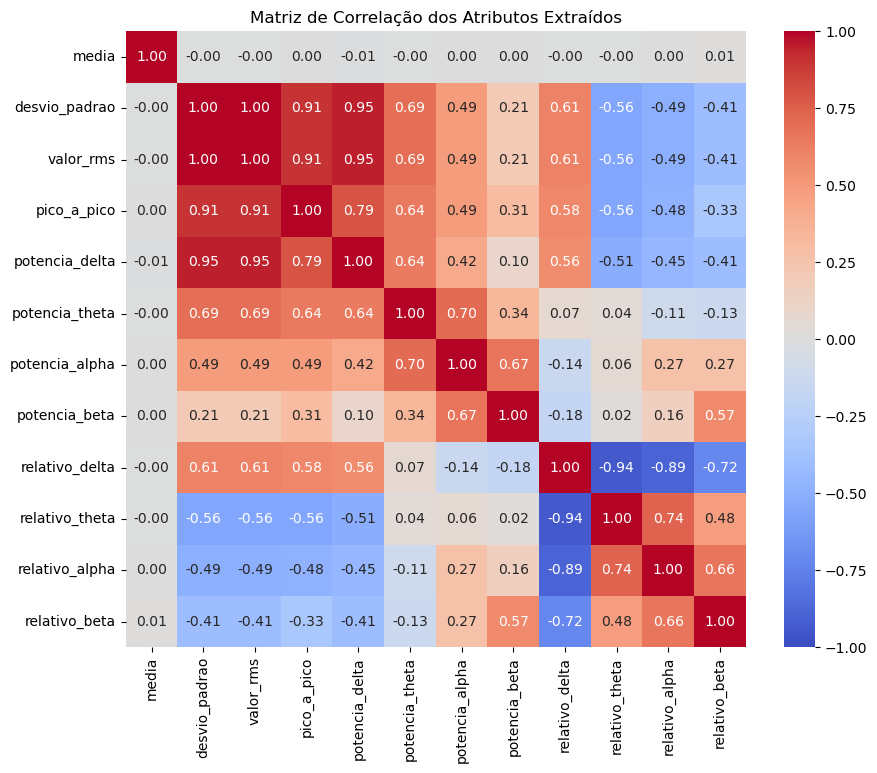

In [262]:
# Lista de colunas de entrada (Features). Apenas as colunas numéricas de atributos.
features_cols = [
    "media", "desvio_padrao", "valor_rms", "pico_a_pico",
    "potencia_delta", "potencia_theta", "potencia_alpha", "potencia_beta",
    "relativo_delta", "relativo_theta", "relativo_alpha", "relativo_beta"
]
matriz_corr = df[features_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação dos Atributos Extraídos")
plt.show()

Conforme observado na matriz de correlação, atributos como `valor_rms` e `potencia_delta` possuem correlação de 0,95, sendo redundantes. Vamos testar o modelo removendo variáveis altamente correlacionadas ou menos informativas para diminuir a complexidade.

## Implementação do Modelo com Atributos Reduzidos

In [263]:
# Lista de colunas de entrada (Features). Removendo RMS e mantendo Potências e Relativos para classificação
features_cols = [
    'variancia', 'desvio_padrao', 'assimetria', 'curtose_excesso',
    'potencia_delta', 'potencia_theta', 'potencia_alpha', 'potencia_beta',
    'relativo_delta', 'relativo_theta', 'relativo_alpha', 'relativo_beta'
]

X = df[features_cols]
y = df['id_estagio'] # Alvo numérico para classificação

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (4257, 12)
Shape de y: (4257,)


## Divisão Treino/Teste com Estratificação

Como a base é desbalanceada (predominância de N2 e raridade de N1), a divisão estratificada é obrigatória para manter a proporção original das classes em ambos os conjuntos.

In [264]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Divisão 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42)

print(f"Treino: {X_train.shape} épocas | Teste: {X_test.shape} épocas")

Treino: (2979, 12) épocas | Teste: (1278, 12) épocas


## Seleção de *k*

Para encontrar o melhor *k*, utilizaremos a Validação Cruzada Estratificada aplicada ao conjunto de treino. A escolha de *k* será baseada na média de acurácia de 5 partições (folds), garantindo que a proporção dos estágios de sono seja respeitada em cada divisão. O uso do `Pipeline` é mandatório aqui para que a padronização seja recalculada em cada partição, evitando o "vazamento de dados".

In [265]:
# Valores candidatos para k.
# Usamos apenas valores ímpares para reduzir a chance de empate na votação.
k_values = list(range(1, 42, 2))

# StratifiedKFold mantém proporções semelhantes das classes em cada fold.
# Validação cruzada estratificada com 5 folds, embaralhamento e semente fixa para reprodutibilidade.
# Embaralhamento é misturar aleatoriamente a ordem das amostras antes de dividi-las em folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
cv_means = []
cv_stds = []
test_scores = []

for k in k_values:
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='manhattan')),
    ])

    # Acurácia no treino: útil para observar tendência de sobreajuste.
    knn_model.fit(X_train, y_train)
    train_scores.append(knn_model.score(X_train, y_train))
    test_scores.append(knn_model.score(X_test, y_test))

    # Acurácia de validação cruzada:
    # o modelo é refeito em cada fold, sempre com o scaler dentro do pipeline.
    scores = cross_val_score(knn_model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

# Melhor k segundo a média de validação cruzada.
best_idx = int(np.argmax(cv_means))
best_k = k_values[best_idx]
best_cv = cv_means[best_idx]

print(f"Melhor k por validação cruzada: {best_k}")
print(f"Acurácia média de validação: {best_cv:.3f}")

Melhor k por validação cruzada: 11
Acurácia média de validação: 0.810


## Curva de Desempenho e Compromisso Viés-Variância

Este gráfico compara a acurácia nos três cenários:

- Treino (Azul): Tende a 100% com k = 1, indicando alta variância (*overfitting*).
- Validação Cruzada (Verde): Estimativa mais segura do desempenho real.
- Teste (Laranja): O desempenho final nas amostras que o modelo nunca viu.

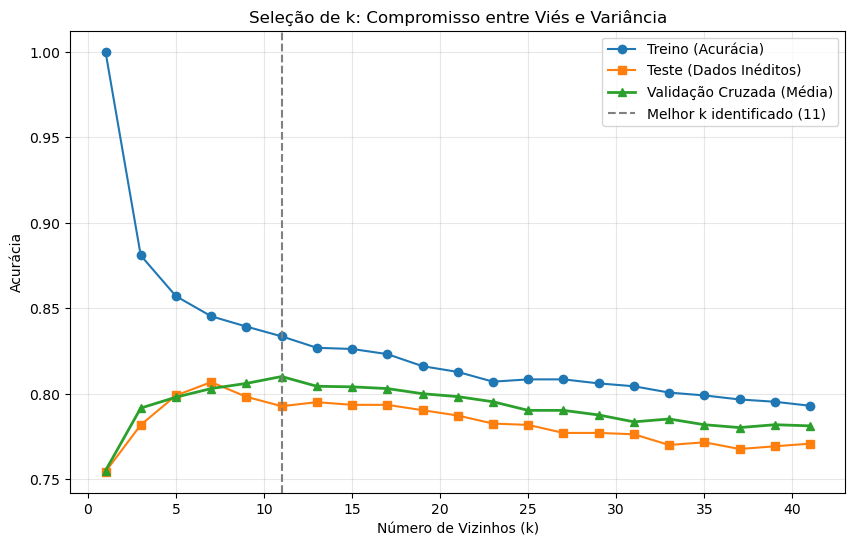

In [266]:
# Visualização dos resultados
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Treino (Acurácia)', color='#1f77b4')
plt.plot(k_values, test_scores, marker='s', label='Teste (Dados Inéditos)', color='#ff7f0e')
plt.plot(k_values, cv_means, marker='^', label='Validação Cruzada (Média)', color='#2ca02c', linewidth=2)

# Linha vertical no melhor k identificado anteriormente
plt.axvline(best_k, color='gray', linestyle='--', label=f'Melhor k identificado ({best_k})')

plt.title('Seleção de k: Compromisso entre Viés e Variância')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Avaliação de Desempenho

Acurácia no teste: 0.771

Relatório de Classificação:
              precision    recall  f1-score   support

    Acordado       0.87      0.50      0.64       207
          N1       0.55      0.22      0.32        95
          N2       0.80      0.90      0.85       554
          N3       0.76      0.93      0.84       216
         REM       0.69      0.79      0.73       206

    accuracy                           0.77      1278
   macro avg       0.73      0.67      0.67      1278
weighted avg       0.77      0.77      0.75      1278



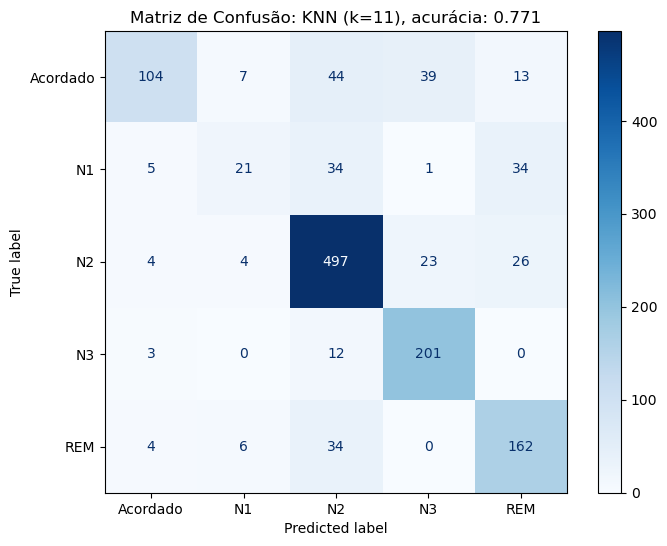


Relatório detalhado por classe:
Acordado: 104/207 (Acurácia: 0.502)
N1: 21/95 (Acurácia: 0.221)
N2: 497/554 (Acurácia: 0.897)
N3: 201/216 (Acurácia: 0.931)
REM: 162/206 (Acurácia: 0.786)


In [267]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
import matplotlib.pyplot as plt

# Realizar previsões no conjunto de teste otimizado
y_pred_opt = knn_model.predict(X_test)

# Gerar a Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_opt,
    display_labels=IdPraClassificacao.values(),
    cmap="Blues",
    ax=ax
)

test_accuracy = accuracy_score(y_test, y_pred_opt)
print(f"Acurácia no teste: {test_accuracy:.3f}")

# Relatório por classe: precisão, recall e F1-score.
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_opt, target_names=IdPraClassificacao.values()))

ax.set_title(f"Matriz de Confusão: KNN (k={best_k}), acurácia: {test_accuracy:.3f}")
ax.grid(False)
plt.show()

print("\nRelatório detalhado por classe:")
acordado_total = (y_test == 1).sum()
acordado_correct = ((y_test == 1) & (y_pred_opt ==  1)).sum()
print(f"Acordado: {acordado_correct}/{acordado_total} (Acurácia: {acordado_correct/acordado_total:.3f})")

n1_total = (y_test == 2).sum()
n1_correct = ((y_test == 2) & (y_pred_opt == 2  )).sum()
print(f"N1: {n1_correct}/{n1_total} (Acurácia: {n1_correct/n1_total:.3f})")

n2_total = (y_test == 3).sum()
n2_correct = ((y_test == 3) & (y_pred_opt == 3  )).sum()
print(f"N2: {n2_correct}/{n2_total} (Acurácia: {n2_correct/n2_total:.3f})")

n3_total = (y_test == 4).sum()
n3_correct = ((y_test == 4) & (y_pred_opt == 4  )).sum()
print(f"N3: {n3_correct}/{n3_total} (Acurácia: {n3_correct/n3_total:.3f})")

rem_total = (y_test == 5).sum()
rem_correct = ((y_test == 5) & (y_pred_opt == 5  )).sum()
print(f"REM: {rem_correct}/{rem_total} (Acurácia: {rem_correct/rem_total:.3f})")